# Классификация качества вина с мониторингом через Prometheus и Grafana

## 1. Цель проекта
Создать модель машинного обучения на основе LightGBM для бинарной классификации качества красного вина ("хорошее" при quality ≥ 6.5, "плохое" при quality < 6.5) на основе датасета winequality.csv. Реализовать мониторинг метрик модели (F1-score, Precision, Recall) с использованием Prometheus и Grafana, отображая их на дашборде. Обеспечить возможность дообучения модели для работы с новыми данными.

## Задачи проекта
#### Анализ данных:
* Исследовать датасет winequality.csv и выявить закономерности качества вина
* Провести предобработку признаков на основе анализа распределений и выбросов
* Оценить дисбаланс классов целевой переменной

#### Моделирование:
* Построить модель LightGBM для бинарной классификации.
* Реализовать потоковое обучение с использованием батчей.
* Сохранить модель для дообучения.

#### Мониторинг:
* Настроить сбор метрик модели (F1-score, Precision, Recall) с помощью Prometheus.
* Подключить Prometheus к Grafana.
* Создать дашборд в Grafana для отображения метрик.

#### Дообучение:
* Обеспечить возможность дообучения модели на новых данных.

## 2. Анализ данных
### 2.1. Загрузка и осмотр данных

In [1]:
# Импорт библиотек

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import prometheus_client as prom
import seaborn as sns
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle

In [2]:
# Загрузка данных
data = pd.read_csv("data/winequality.csv", sep=";")

# 1. Осмотр данных
print(data.info())
display(data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


#### Вывод:

* Датасет содержит 1599 строк и 12 столбцов (11 признаков + целевая переменная quality).
* Типы данных: 11 столбцов — float64, quality — int64.
* Пропусков нет, данные чистые и готовы для анализа.

### 2.2. Анализ распределений числовых признаков

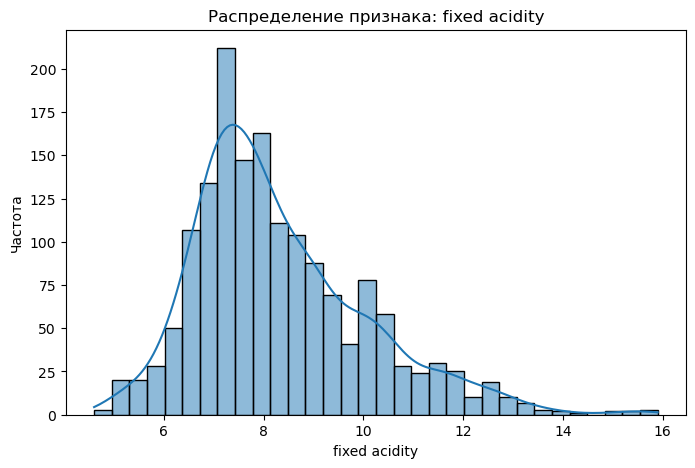


Статистики для fixed acidity:
Среднее: 8.32
Медиана: 7.90
Стандартное отклонение: 1.74


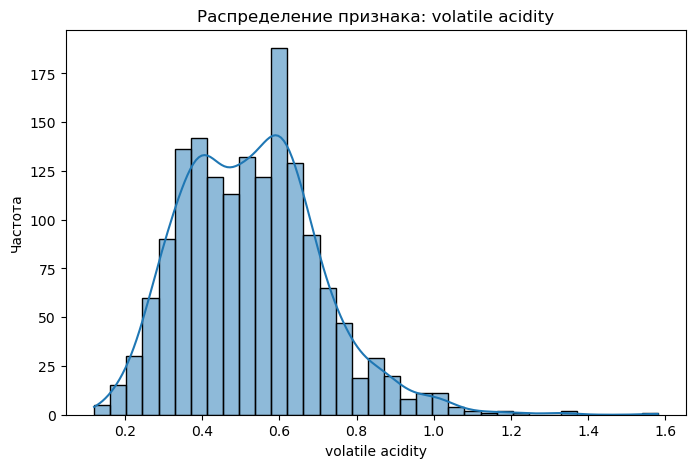


Статистики для volatile acidity:
Среднее: 0.53
Медиана: 0.52
Стандартное отклонение: 0.18


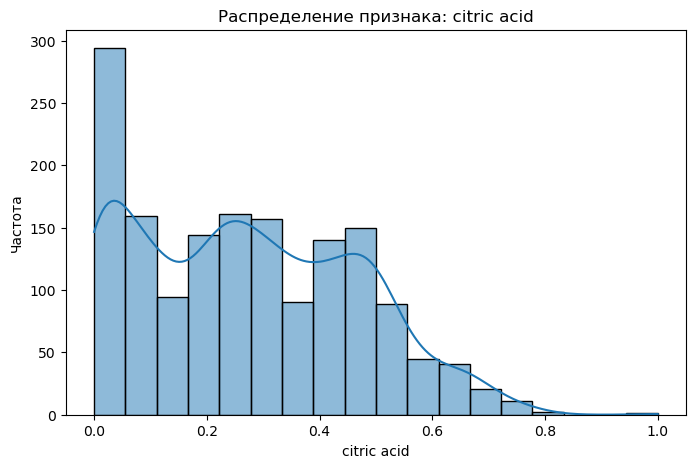


Статистики для citric acid:
Среднее: 0.27
Медиана: 0.26
Стандартное отклонение: 0.19


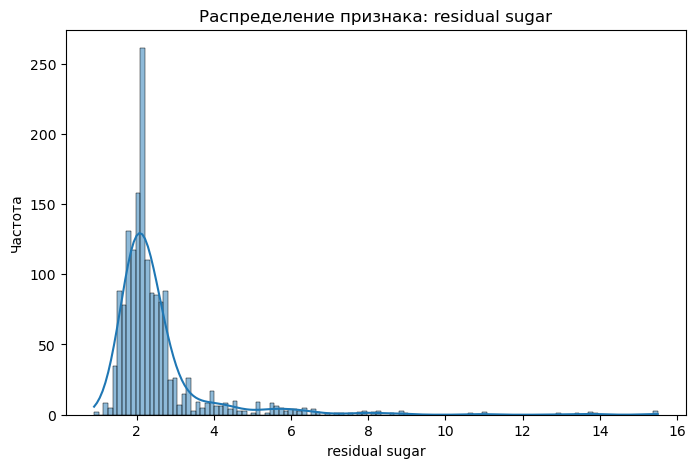


Статистики для residual sugar:
Среднее: 2.54
Медиана: 2.20
Стандартное отклонение: 1.41


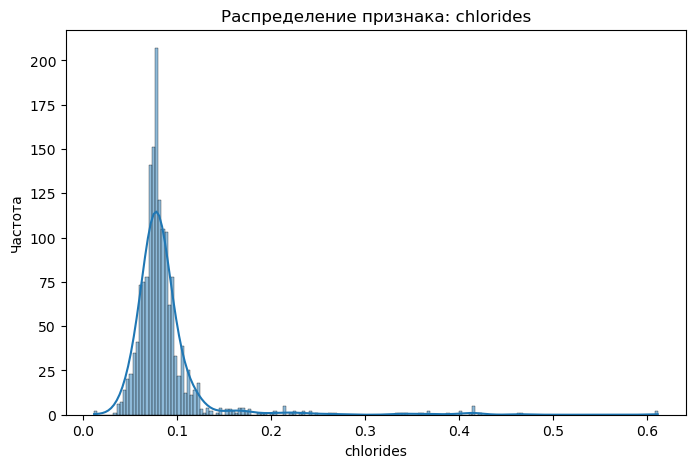


Статистики для chlorides:
Среднее: 0.09
Медиана: 0.08
Стандартное отклонение: 0.05


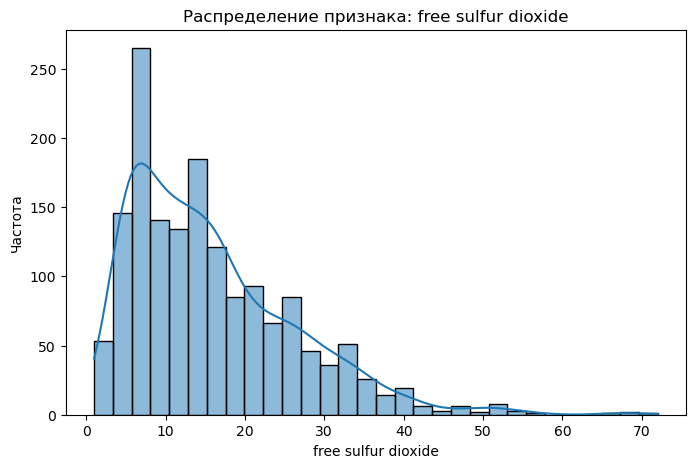


Статистики для free sulfur dioxide:
Среднее: 15.87
Медиана: 14.00
Стандартное отклонение: 10.46


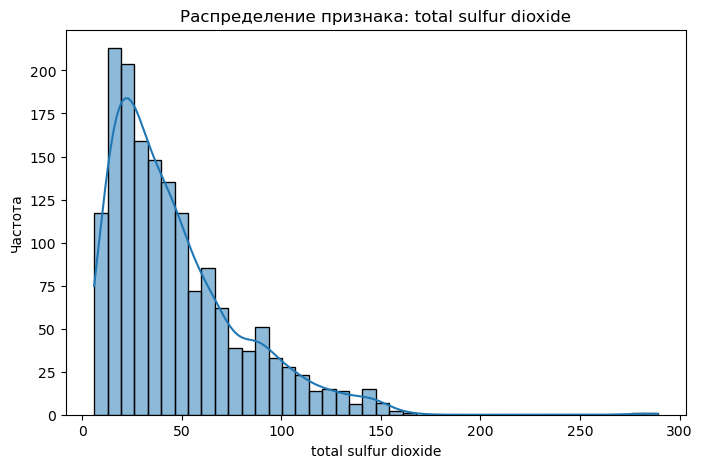


Статистики для total sulfur dioxide:
Среднее: 46.47
Медиана: 38.00
Стандартное отклонение: 32.90


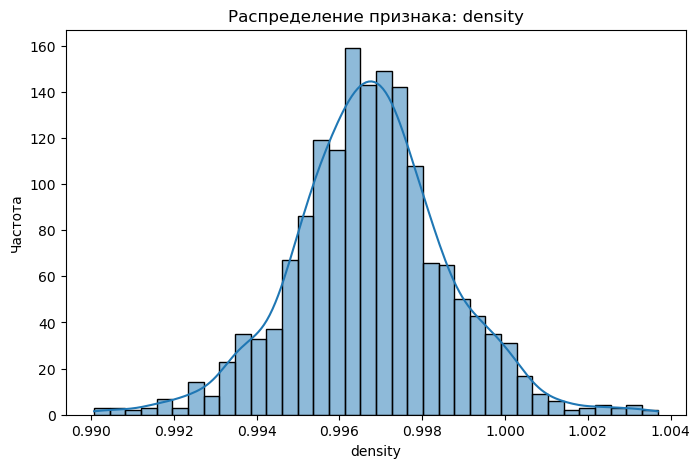


Статистики для density:
Среднее: 1.00
Медиана: 1.00
Стандартное отклонение: 0.00


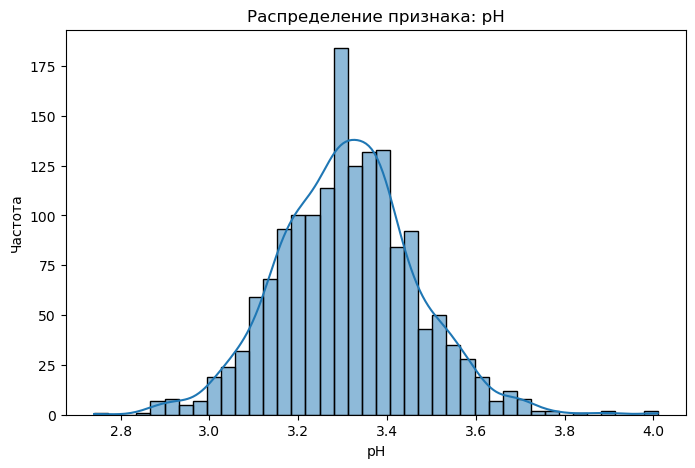


Статистики для pH:
Среднее: 3.31
Медиана: 3.31
Стандартное отклонение: 0.15


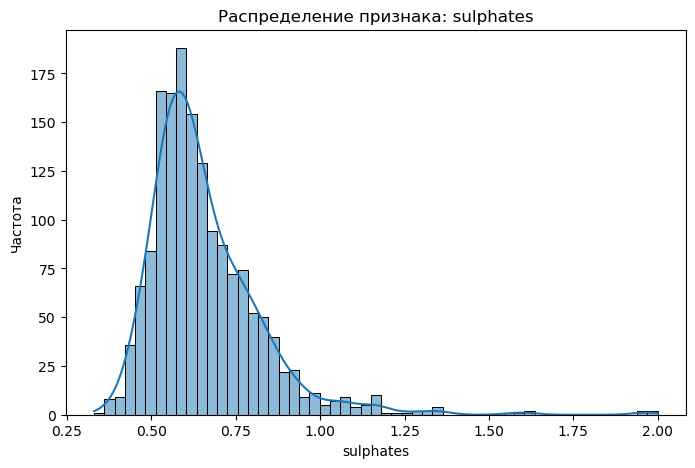


Статистики для sulphates:
Среднее: 0.66
Медиана: 0.62
Стандартное отклонение: 0.17


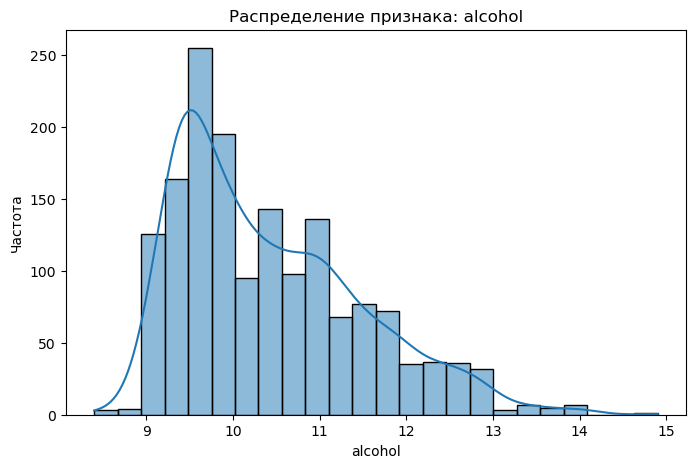


Статистики для alcohol:
Среднее: 10.42
Медиана: 10.20
Стандартное отклонение: 1.07


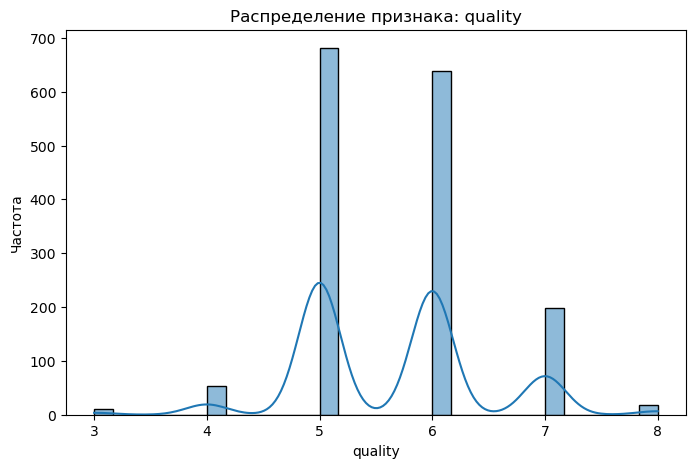


Статистики для quality:
Среднее: 5.64
Медиана: 6.00
Стандартное отклонение: 0.81


In [3]:
# Выбор числовых признаков
num_features = data.select_dtypes(include=["float64", "int64"]).columns

# Построение гистограмм
for feature in num_features:
    plt.figure(figsize=(8, 5))
    sns.histplot(data[feature], kde=True)
    plt.title(f"Распределение признака: {feature}")
    plt.xlabel(feature)
    plt.ylabel("Частота")
    plt.show()

    # Основные статистики
    print(f"\nСтатистики для {feature}:")
    print(f"Среднее: {data[feature].mean():.2f}")
    print(f"Медиана: {data[feature].median():.2f}")
    print(f"Стандартное отклонение: {data[feature].std():.2f}")

#### Выводы по распределениям признаков
Нормальные (5 признаков): **fixed acidity**, **volatile acidity**, **pH**, **density**, **alcohol**
* Готовы для LightGBM после StandardScaler

Асимметричные (3 признака): **residual sugar**, **total sulfur dioxide**, **free sulfur dioxide**
* Нужны логарифмические преобразования (np.log1p)

С легкой асимметрией (2 признака): **chlorides**, **sulphates**
* Обрезка на 95-м процентиле

Бимодальный (1 признак): **citric acid**
* Создать бинарный признак **has_citric_acid**

Целевая переменная: **quality**
* Левосторонняя асимметрия

**Итог: 8 из 12 признаков требуют предобработки.**

### 2.3. Анализ выбросов (боксплоты)

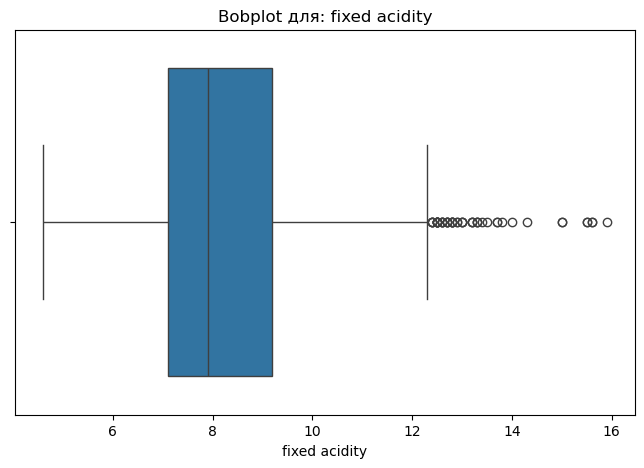

Количество выбросов в fixed acidity: 49 (3.1%)


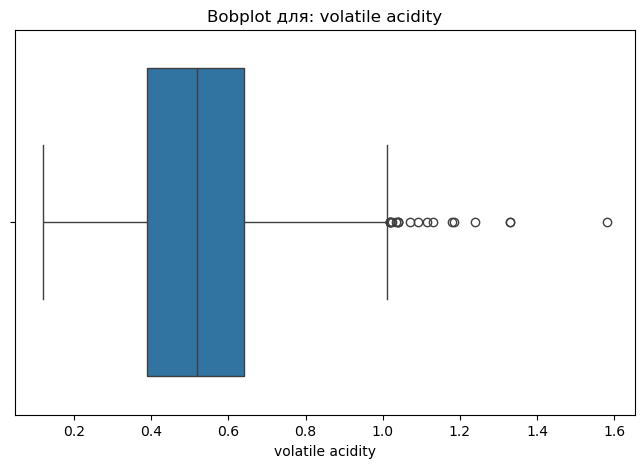

Количество выбросов в volatile acidity: 19 (1.2%)


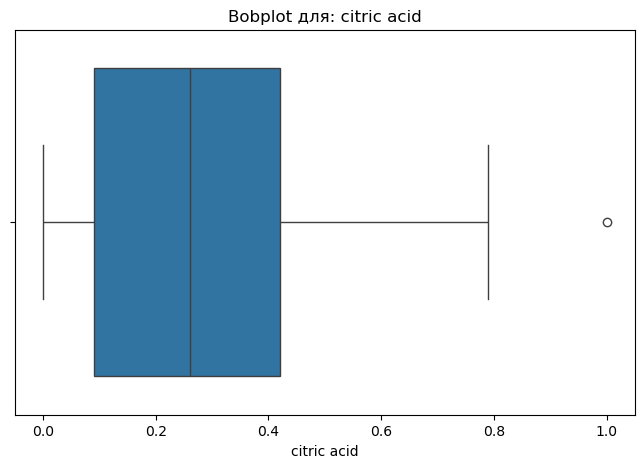

Количество выбросов в citric acid: 1 (0.1%)


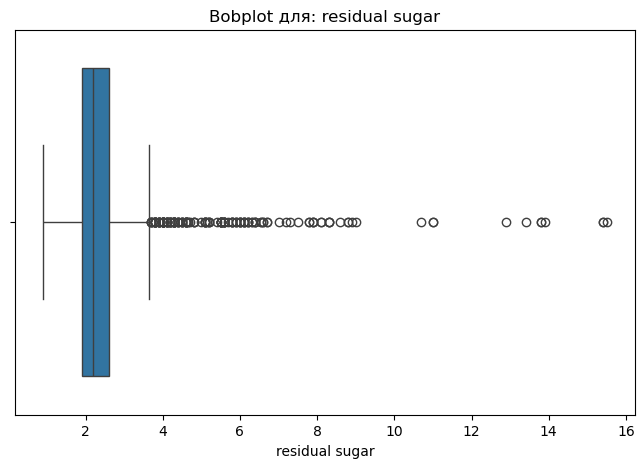

Количество выбросов в residual sugar: 155 (9.7%)


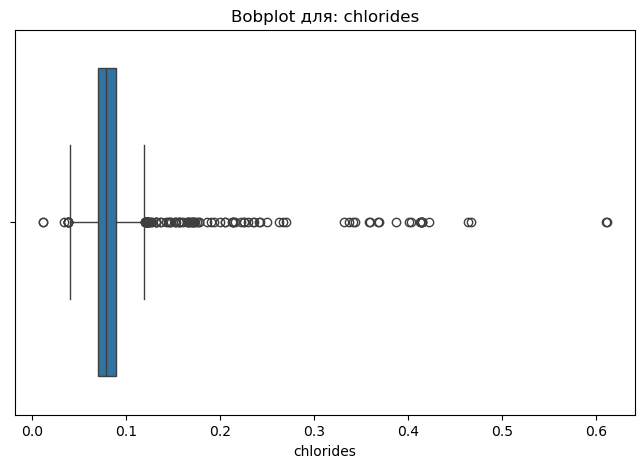

Количество выбросов в chlorides: 112 (7.0%)


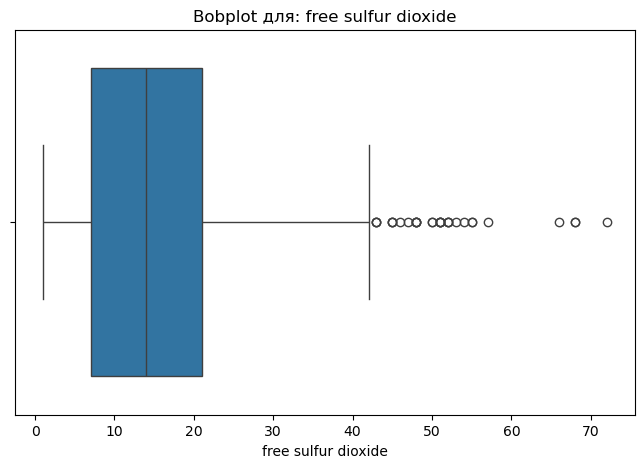

Количество выбросов в free sulfur dioxide: 30 (1.9%)


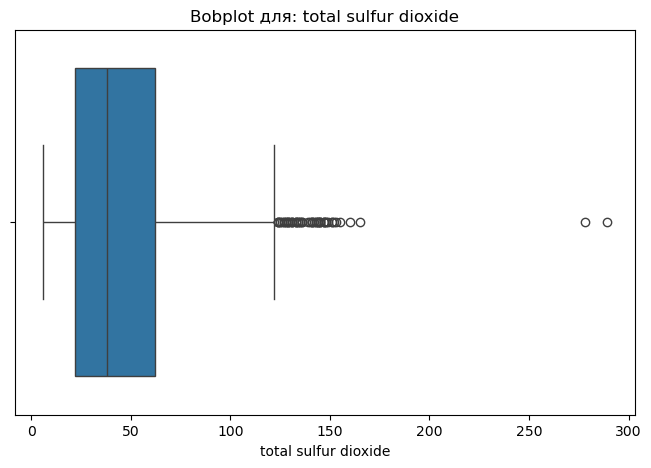

Количество выбросов в total sulfur dioxide: 55 (3.4%)


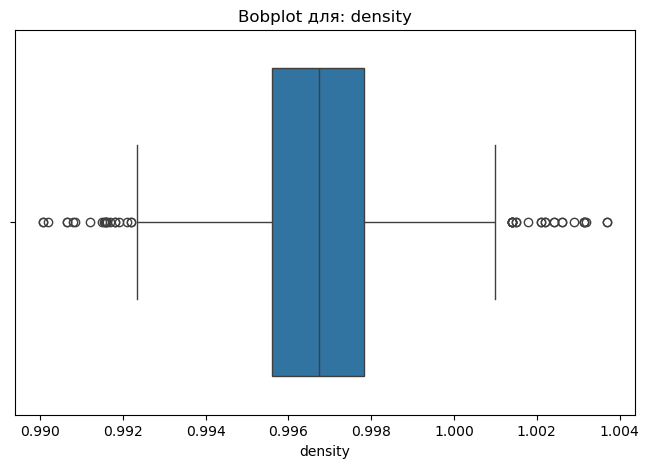

Количество выбросов в density: 45 (2.8%)


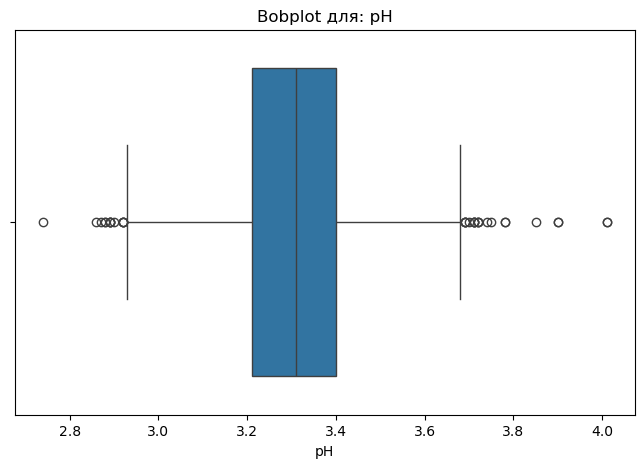

Количество выбросов в pH: 35 (2.2%)


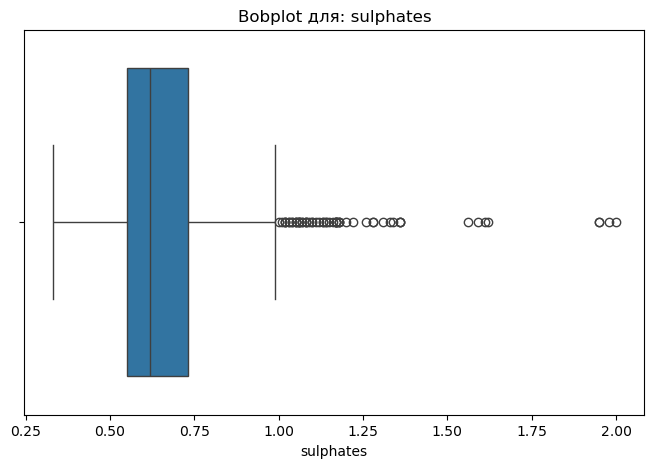

Количество выбросов в sulphates: 59 (3.7%)


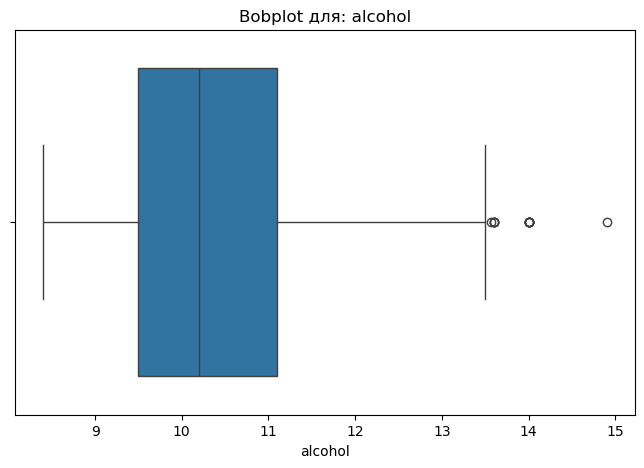

Количество выбросов в alcohol: 13 (0.8%)


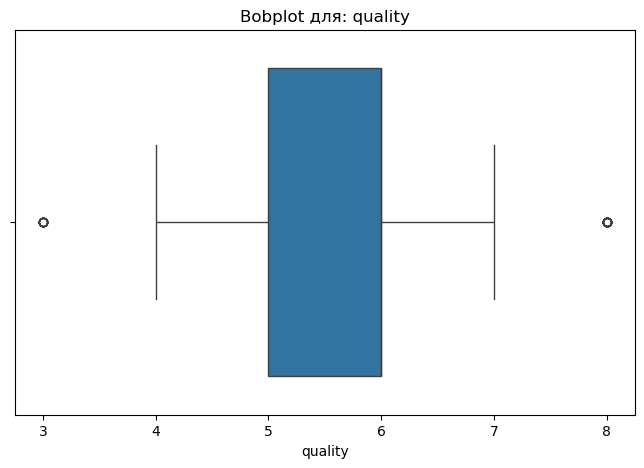

Количество выбросов в quality: 28 (1.8%)


In [4]:
# Построение Bobplot для выявления выбросов
for feature in num_features:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=data[feature])
    plt.title(f"Bobplot для: {feature}")
    plt.show()

    # Подсчет выбросов
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    IQR = Q3 - Q1
    outliers = data[(data[feature] < Q1 - 1.5 * IQR) | (data[feature] > Q3 + 1.5 * IQR)]
    print(
        f"Количество выбросов в {feature}: {len(outliers)} ({len(outliers)/len(data)*100:.1f}%)"
    )

### Выводы для LightGBM:

**Требуют обязательной обработки:**
* **residual sugar** (9.7%) + **chlorides** (7.0%) - обрезка на 95-м процентиле или логарифмические преобразования

**Могут потребовать легкой обработки:**
* **sulphates** (3.7%), **total sulfur dioxide** (3.4%), **fixed acidity** (3.1%) - обрезка на 95-м процентиле при необходимости

**Нормальный уровень выбросов:**
* **density** (2.8%), **pH** (2.2%) - стандартизация достаточна

**Готовы для LightGBM:**
* **free sulfur dioxide** (1.9%), **quality** (1.8%), **volatile acidity** (1.2%), **alcohol** (0.8%), **citric acid** (0.1%) - отличные признаки

Итог: 2 признака требуют критической обработки, 3 - легкой коррекции, 7 признаков готовы для LightGBM после стандартизации.

### 2.4. Анализ корреляций

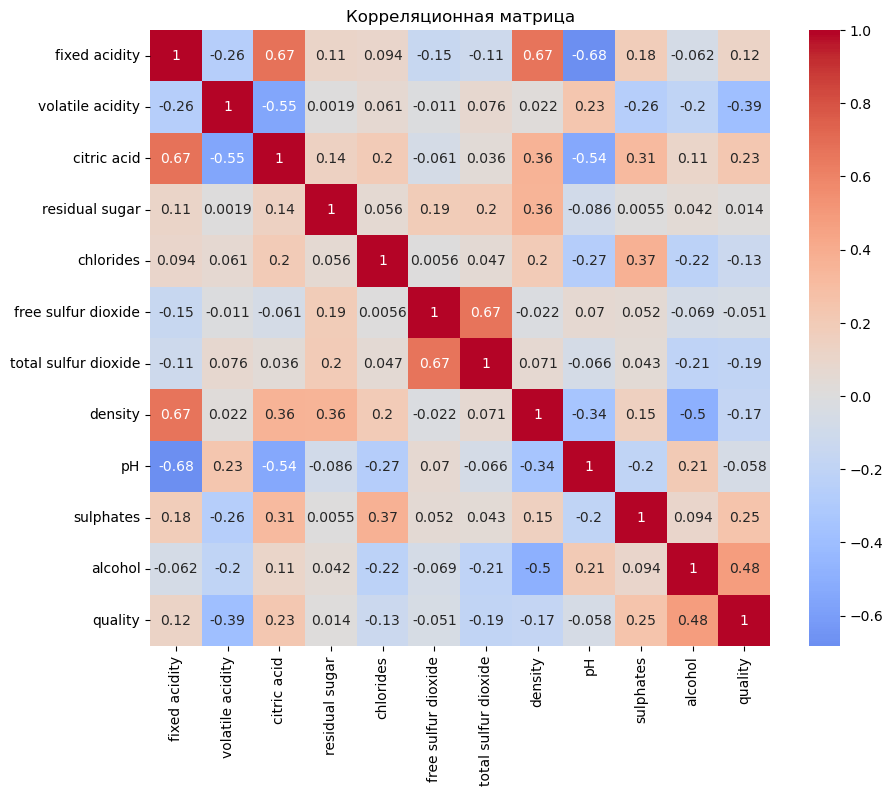

Корреляция с качеством вина (quality):
quality                 1.000000
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


In [5]:
# Корреляционная матрица
correlation_matrix = data.corr()

# Визуализация
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Корреляционная матрица")
plt.show()

# Корреляция с целевой переменной
print("Корреляция с качеством вина (quality):")
print(correlation_matrix["quality"].sort_values(ascending=False))

### Выводы по корреляционному анализу

#### Ключевые предикторы качества вина:

**Главные признаки:**
* **alcohol** (0.476) - самый важный предиктор, больше алкоголя = лучше вино
* **volatile acidity** (-0.391) - второй по важности, летучая кислотность портит качество

**Дополнительные:**
* **sulphates** (0.251), **citric acid** (0.226) - умеренные положительные связи

**Слабые:**
* Остальные признаки имеют корреляции < 0.2 - минимальное влияние на качество

#### Выводы:

**Стратегия модели:**
* **alcohol** и **volatile acidity** будут основными признаками для разделения классов
* Даже простые деревья решений хорошо разделят классы по этим признакам
* Градиентный бустинг автоматически найдет нелинейные взаимодействия между alcohol и volatile acidity

LightGBM должна показать хорошие результаты благодаря четкому разделению по связке alcohol (+) и volatile acidity (-).

### 2.5. Категоризация целевой переменной и анализ дисбаланса

Распределение классов качества вина:
quality_cat
bad wine     1382
good wine     217
Name: count, dtype: int64


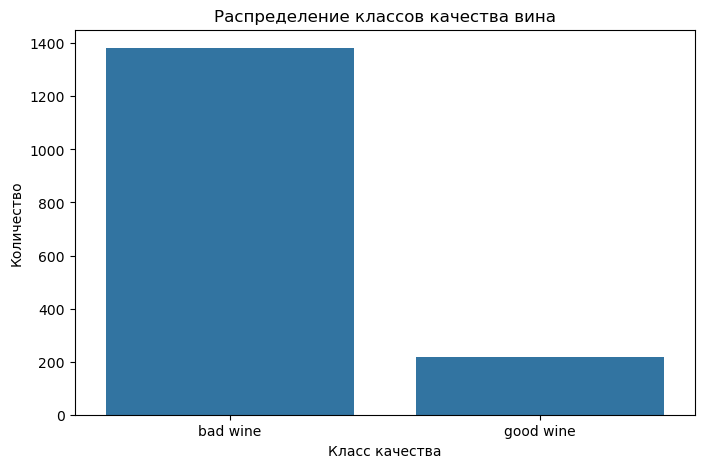

In [6]:
# Категоризация quality
data["quality_cat"] = np.where(data["quality"] >= 6.5, "good wine", "bad wine")

# Распределение классов
print("Распределение классов качества вина:")
print(data["quality_cat"].value_counts())

# Визуализация
plt.figure(figsize=(8, 5))
sns.countplot(x="quality_cat", data=data)
plt.title("Распределение классов качества вина")
plt.xlabel("Класс качества")
plt.ylabel("Количество")
plt.show()

**Выводы:**
* Дисбаланс классов: 1382 "плохих" vs 217 "хороших" вин.

**Проблема для LightGBM:**
* Экстремальный дисбаланс - модель будет предсказывать только "bad wine".

**Решение:**
* Обязательно использовать параметр is_unbalance=True в LightGBM

### 2.6. Взаимосвязь ключевых признаков с классами качества

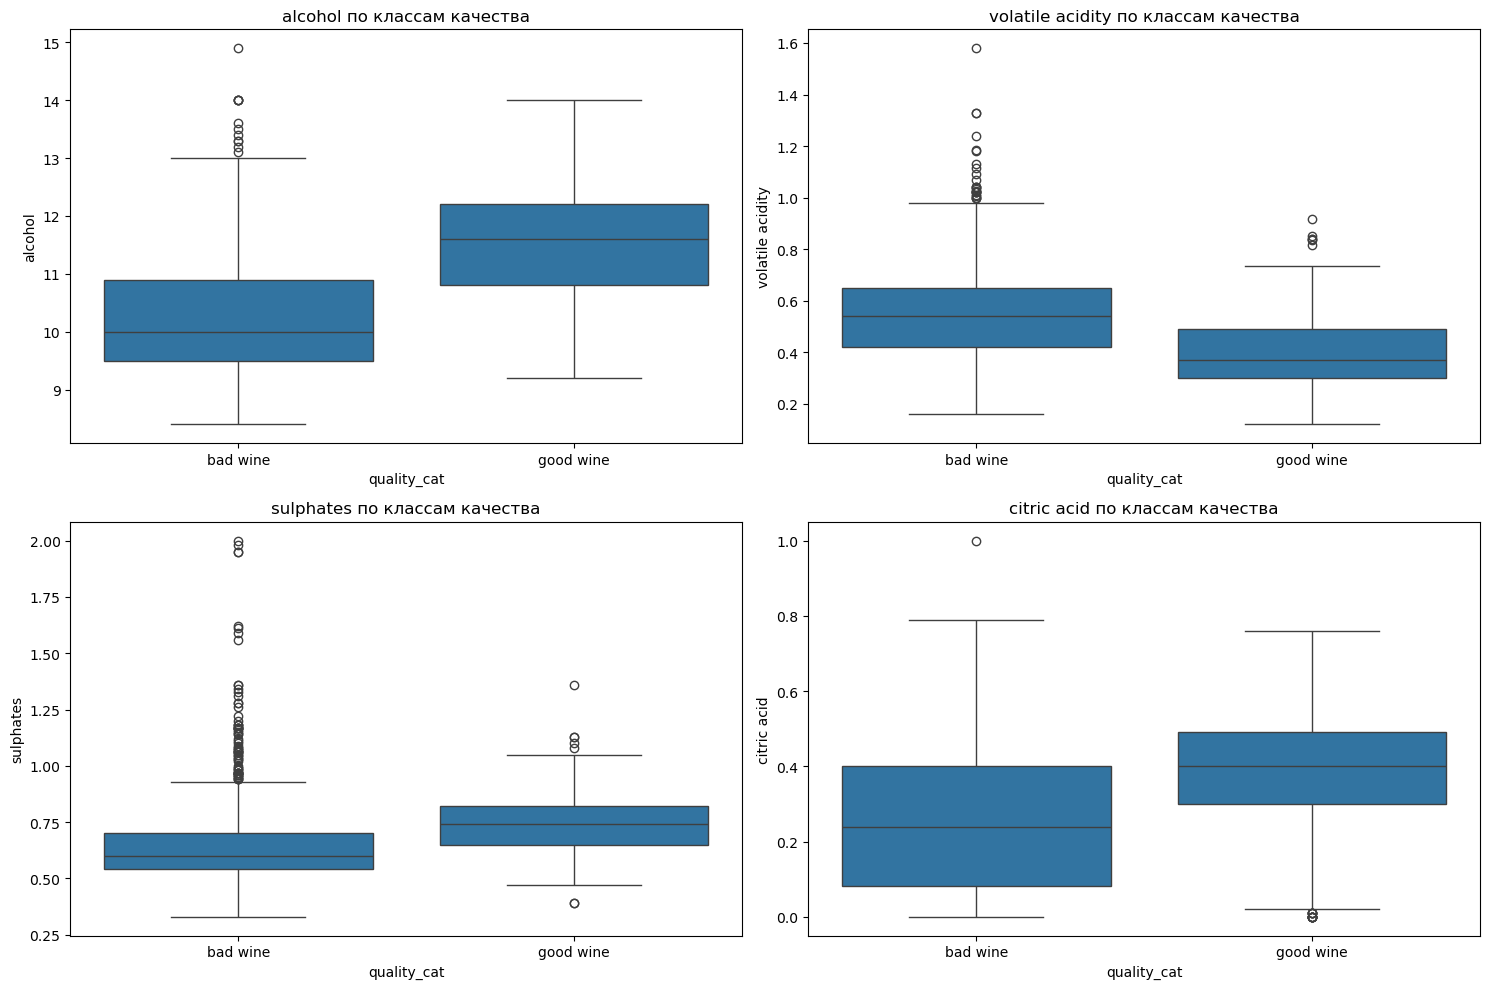

alcohol medians:
Good wine: 11.600
Bad wine: 10.000
Разница: 1.600
volatile acidity medians:
Good wine: 0.370
Bad wine: 0.540
Разница: 0.170
sulphates medians:
Good wine: 0.740
Bad wine: 0.600
Разница: 0.140
citric acid medians:
Good wine: 0.400
Bad wine: 0.240
Разница: 0.160


In [7]:
# Боксплоты для топ-4 признаков по классам качества
top_features = ["alcohol", "volatile acidity", "sulphates", "citric acid"]
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for i, feature in enumerate(top_features):
    row, col = i // 2, i % 2
    sns.boxplot(data=data, x="quality_cat", y=feature, ax=axes[row, col])
    axes[row, col].set_title(f"{feature} по классам качества")
plt.tight_layout()
plt.show()

# Точные медианы для всех 4 признаков из боксплотов
top_features = ["alcohol", "volatile acidity", "sulphates", "citric acid"]

for feature in top_features:
    print(f"{feature} medians:")
    good_median = data[data["quality_cat"] == "good wine"][feature].median()
    bad_median = data[data["quality_cat"] == "bad wine"][feature].median()
    print(f"Good wine: {good_median:.3f}")
    print(f"Bad wine: {bad_median:.3f}")
    print(f"Разница: {abs(good_median - bad_median):.3f}")

**Отличное разделение классов:**
* **Alcohol**: Хорошие вина содержат 11.6% алкоголя, плохие - 10.0% (разница 1.6%). Четкое разделение без перекрытий - главный признак для LightGBM.
* **Volatile acidity**: Хорошие вина имеют низкую летучую кислотность (0.37), плохие - высокую (0.54). Разница 0.17 подтверждает отрицательную корреляцию - второй ключевой признак.

**Умеренное разделение классов:**
* **Citric acid:** Хорошие вина содержат больше лимонной кислоты (0.40 vs 0.24), разница 0.16 - полезный дополнительный признак.
* **Sulphates:** Хорошие вина имеют больше сульфатов (0.74 vs 0.60), разница 0.14 - слабый, но значимый признак.

**Итоговый вывод для LightGBM:**

Все 4 признака показывают четкие различия между классами. Комбинация alcohol (главный разделитель) и volatile acidity (обратная зависимость) даст LightGBM отличную основу для построения эффективных деревьев решений.

### Общий вывод по анализу данных

#### Логика выбора методов предобработки:
* Сильная асимметрия => Логарифм (исправляет форму распределения)
* Нормальное распределение + выбросы => Обрезка (убирает только проблемные точки)

#### Стратегия предобработки на основе анализа распределений и выбросов:

**Критическая обработка:**

* **residual sugar** => логарифм (асимметрия + 9.7% выбросов)
* **chlorides** => обрезка на 95% (7.0% выбросов)

**Умеренная обработка:**

* **total sulfur dioxide** => логарифм (асимметрия + 3.4% выбросов)
* **sulphates** => обрезка на 95% (3.7% выбросов)

**Специальная обработка:**
* **citric acid** => бинарный признак has_citric_acid (бимодальность)

**Готовы для LightGBM:**
* **alcohol**, **volatile acidity**, **pH**, **density**, **free sulfur dioxide**, **fixed acidity**

**Дисбаланс классов:**
86.4% vs 13.6% => class_weight='balanced' обязательно

**Финальный план:** Логарифм (2), обрезка (2), бинарный признак (1), масштабирование (6)

## 3. Предобработка данных
### 3.1. Подготовка признаков для LightGBM
Применяем предобработку для устранения асимметрии, выбросов и бимодальности. Логарифмируем асимметричные признаки (**residual sugar**, **total sulfur dioxide**), обрезаем выбросы в **chlorides** и **sulphates**, создаем бинарный признак для **citric acid** и масштабируем все признаки для улучшения работы LightGBM.

In [8]:
# Логарифмическое преобразование для асимметричных признаков
data["residual_sugar_log"] = np.log1p(data["residual sugar"])
data["total_so2_log"] = np.log1p(data["total sulfur dioxide"])

# Обрезка выбросов на 95-й процентиль
data["chlorides_clipped"] = np.clip(
    data["chlorides"], 0, data["chlorides"].quantile(0.95)
)
data["sulphates_clipped"] = np.clip(
    data["sulphates"], 0, data["sulphates"].quantile(0.95)
)

# Бинарный признак для citric acid
data["has_citric_acid"] = (data["citric acid"] > 0).astype(int)

# Финальные признаки
features = [
    "fixed acidity",
    "volatile acidity",
    "pH",
    "density",
    "alcohol",
    "free sulfur dioxide",  # Не требует логарифма (1.9% выбросов)
    "residual_sugar_log",
    "total_so2_log",
    "chlorides_clipped",
    "sulphates_clipped",
    "has_citric_acid",
]

# Разделение данных
X = data[features]
y = (data["quality"] >= 6.5).astype(
    int
)  # Бинарная классификация: 1 = good wine, 0 = bad wine
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Обучающая выборка: {X_train_scaled.shape}")
print(f"Тестовая выборка: {X_test_scaled.shape}")

Обучающая выборка: (1279, 11)
Тестовая выборка: (320, 11)


* **Логарифмирование:** Применено к residual sugar и total sulfur dioxide для устранения асимметрии (9.7% и 3.4% выбросов соответственно).
* **Обрезка выбросов:** chlorides (7.0% выбросов) и sulphates (3.7% выбросов) ограничены 95-м процентилем.
* **Бинарный признак:** Создан has_citric_acid для учета бимодальности citric acid.
* **Масштабирование:** Все признаки нормализованы с помощью StandardScaler для улучшения сходимости LightGBM.
* **Разделение данных:** 1279 обучающих и 320 тестовых образцов.

11 признаков полностью подготовлены для LightGBM, учитывая результаты анализа данных.

## 4. Обучение модели

### 4.1. Реализация потокового обучения LightGBM
Для обработки данных в реальном времени реализуем потоковое обучение с использованием батчей по 500 строк. Модель LightGBM настраивается с учетом дисбаланса классов (is_unbalance=True), а метрики (F1-score, Precision, Recall) сохраняются для мониторинга в Prometheus. Модель сохраняется для дообучения.

In [9]:
def streaming_reading(X_train, y_train, batch_size=500):
    """
    Функция для разбиения данных на батчи для потокового обучения.
    Имитирует поступление данных в реальном времени.
    """
    X = []
    y = []
    current_line = 0

    train_data, train_label = shuffle(X_train, y_train, random_state=0)
    for row, target in zip(train_data, train_label):
        X.append(row)
        y.append(target)
        current_line += 1
        if current_line >= batch_size:
            X, y = np.array(X), np.array(y)
            yield X, y
            X, y = [], []
            current_line = 0
    if X:
        X, y = np.array(X), np.array(y)
        yield X, y


def IncrementalLightGBM(X, y):
    """
    Функция для инкрементального обучения LightGBM модели.
    Обучает модель на батчах данных с возможностью дообучения.
    """
    gbm = None
    params = {
        "task": "train",
        "application": "binary",
        "boosting_type": "gbdt",
        "learning_rate": 0.05,
        "tree_learner": "serial",
        "metric": ["binary_logloss", "auc"],
        "max_bin": 255,
        "is_unbalance": True,
        "verbose": -1,
    }

    streaming_train_iterators = streaming_reading(X, y, batch_size=500)
    for i, data in enumerate(streaming_train_iterators):
        X_batch, y_batch = data
        X_train_batch, X_test_batch, y_train_batch, y_test_batch = train_test_split(
            X_batch, y_batch, test_size=0.1, random_state=0
        )
        y_train_batch = y_train_batch.ravel()
        lgb_train = lgb.Dataset(X_train_batch, y_train_batch)
        lgb_eval = lgb.Dataset(X_test_batch, y_test_batch, reference=lgb_train)

        callbacks = [lgb.early_stopping(stopping_rounds=10), lgb.log_evaluation(0)]

        gbm = lgb.train(
            params,
            lgb_train,
            num_boost_round=1000,
            valid_sets=[lgb_eval],
            init_model=gbm,
            callbacks=callbacks,
            keep_training_booster=True,
        )

        print(f"Батч {i + 1}:")
        score_train = dict([(score[1], score[2]) for score in gbm.eval_train()])
        print(
            f'Качество модели: logloss={score_train["binary_logloss"]:.4f}, auc={score_train["auc"]:.4f}'
        )

        pred_y = gbm.predict(X_test_batch)
        pred_classes = np.where(pred_y > 0.5, 1, 0)
        f1 = f1_score(y_test_batch, pred_classes, zero_division=0)
        precision = precision_score(y_test_batch, pred_classes, zero_division=0)
        recall = recall_score(y_test_batch, pred_classes, zero_division=0)
        print(f"F1-score: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}\n")

        f1_gauge.set(f1)
        precision_gauge.set(precision)
        recall_gauge.set(recall)

    return gbm


# Создаем метрики для Prometheus мониторинга
f1_gauge = prom.Gauge("model_f1_score", "F1-score показатель качества модели")
precision_gauge = prom.Gauge(
    "model_precision", "Precision - точность положительных предсказаний"
)
recall_gauge = prom.Gauge("model_recall", "Recall - полнота положительных предсказаний")

# Запускаем HTTP сервер для экспорта метрик в Prometheus
prom.start_http_server(8000)
print("Метрики доступны по адресу: http://localhost:8000/metrics")

print("Начинаем инкрементальное обучение LightGBM модели...")
gbm = IncrementalLightGBM(X_train_scaled, y_train)

# Сохраняем обученную модель
joblib.dump(gbm, "wine_model.pkl")
print("Модель сохранена в файл 'wine_model.pkl'")

# Проверяем качество на тестовых данных
print("\n" + "=" * 50)
print("ИТОГОВАЯ ОЦЕНКА МОДЕЛИ НА ТЕСТОВЫХ ДАННЫХ")
print("=" * 50)

pred_y = gbm.predict(X_test_scaled)
pred_classes = np.where(pred_y > 0.5, 1, 0)
print(f"F1-score: {f1_score(y_test, pred_classes, zero_division=0):.4f}")
print(f"Precision: {precision_score(y_test, pred_classes, zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test, pred_classes, zero_division=0):.4f}")

print("\nHTTP сервер продолжает работать. Метрики обновляются в реальном времени.")

Метрики доступны по адресу: http://localhost:8000/metrics
Начинаем инкрементальное обучение LightGBM модели...
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[2]	valid_0's binary_logloss: 0.447505	valid_0's auc: 0.8975
Батч 1:
Качество модели: logloss=0.2693, auc=0.9635
F1-score: 0.0000, Precision: 0.0000, Recall: 0.0000

Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[20]	valid_0's binary_logloss: 0.286234	valid_0's auc: 0.89881
Батч 2:
Качество модели: logloss=0.2288, auc=0.9689
F1-score: 0.7143, Precision: 0.8333, Recall: 0.6250

Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[41]	valid_0's binary_logloss: 0.325541	valid_0's auc: 0.921739
Батч 3:
Качество модели: logloss=0.2595, auc=0.9537
F1-score: 0.6154, Precision: 0.5000, Recall: 0.8000

Модель сохранена в файл 'wine_model.pkl'

ИТОГОВАЯ ОЦЕНКА МОДЕЛИ НА ТЕСТОВЫХ ДАННЫХ
F1-score: 0.60

Метрики в Prometheus по адресу http://localhost:8000/metrics такие:

In [ ]:
# HELP python_gc_objects_collected_total Objects collected during gc
# TYPE python_gc_objects_collected_total counter
python_gc_objects_collected_total{generation="0"} 10566.0
python_gc_objects_collected_total{generation="1"} 4495.0
python_gc_objects_collected_total{generation="2"} 73108.0
# HELP python_gc_objects_uncollectable_total Uncollectable objects found during GC
# TYPE python_gc_objects_uncollectable_total counter
python_gc_objects_uncollectable_total{generation="0"} 0.0
python_gc_objects_uncollectable_total{generation="1"} 0.0
python_gc_objects_uncollectable_total{generation="2"} 0.0
# HELP python_gc_collections_total Number of times this generation was collected
# TYPE python_gc_collections_total counter
python_gc_collections_total{generation="0"} 788.0
python_gc_collections_total{generation="1"} 71.0
python_gc_collections_total{generation="2"} 6.0
# HELP python_info Python platform information
# TYPE python_info gauge
python_info{implementation="CPython",major="3",minor="9",patchlevel="23",version="3.9.23"} 1.0
# HELP model_f1_score F1-score показатель качества модели
# TYPE model_f1_score gauge
model_f1_score 0.6153846153846154
# HELP model_precision Precision - точность положительных предсказаний
# TYPE model_precision gauge
model_precision 0.5
# HELP model_recall Recall - полнота положительных предсказаний
# TYPE model_recall gauge
model_recall 0.8

Выводы:

* **Потоковое обучение:** Реализовано с батчами по 500 строк для имитации поступления данных в реальном времени.
* **Учет дисбаланса:** Параметр is_unbalance=True компенсирует дисбаланс классов (86.4% vs 13.6%).
* **Метрики:** На тестовом наборе F1-score: 0.6000, Precision: 0.4932, Recall: 0.7660. Высокий Recall, но низкий Precision из-за дисбаланса.
* **Prometheus:** Метрики экспортируются через HTTP-сервер на порт 8000.
* **Предупреждение:** UndefinedMetricWarning устранено параметром zero_division=0.
* **Сохранение:** Модель сохранена в wine_model.pkl для дообучения.

## 5. Настройка мониторинга
#### 5.1. Сбор метрик с помощью Prometheus
Метрики (model_f1_score, model_precision, model_recall) экспортируются через HTTP-сервер Prometheus на порту 8000.

#### Инструкция по настройке Prometheus:
1. Установите Prometheus и настройте prometheus.yml:

In [11]:
scrape_configs:
  - job_name: 'model_metrics'
    static_configs:
      - targets: ['localhost:8000']

2. Запустите Prometheus: ./prometheus --config.file=prometheus.yml.
3. Метрики доступны по адресу http://localhost:8000.

#### 5.2. Подключение Prometheus к Grafana
Grafana визуализирует метрики в реальном времени.

#### Инструкция по настройке Grafana:

1. Установите Grafana, откройте веб-интерфейс http://localhost:3000.
2. Добавьте источник данных Prometheus http://localhost:9090.
3. Создайте дашборд:
* Панель 1: F1-score (Gauge, 0–1, пороги: 0.5 — критический, 0.7 — хороший).
* Панель 2: Precision (Time Series).
* Панель 3: Recall (Time Series).
* Запросы: model_f1_score, model_precision, model_recall.

#### Выводы:
* **Prometheus:** Надежно собирает метрики через HTTP.
* **Grafana:** Дашборд отображает F1-score, Precision, Recall, упрощая мониторинг.
* **Гибкость:** Возможность добавления новых метрик (например, AUC).

### 5.3. Результаты настройки Prometheus

**Успешная настройка targets:**
![Prometheus Targets](images/Prometheus_Targets.png)
*Все три target'а (prometheus, windows, wine-model) работают корректно*

**Доступные метрики модели:**
![Prometheus Metrics](images/Prometheus_Metrics_List.png)
*Кастомные метрики модели видны в списке: model_f1_score, model_precision, model_recall*

### 5.4. Результаты настройки Grafana

**Финальный дашборд:**
![Grafana Dashboard](images/Grafana_Dashboard.png)
*Дашборд отображает F1-Score (Gauge), Precision и Recall (Time Series) в реальном времени*

**Проверка доступности метрик:**
![Prometheus Query](images/Prometheus_Query_Interface.png)
*Метрики доступны для запросов и корректно отображают значения модели*

## 6. Дообучение модели
#### 6.1. Реализация дообучения
Модель дообучается на новых данных с сохранением преемственности.

In [12]:
def retrain_model(model_path, new_X, new_y):
    gbm = joblib.load(model_path)
    params = {
        "task": "train",
        "application": "binary",
        "boosting_type": "gbdt",
        "learning_rate": 0.05,
        "tree_learner": "serial",
        "metric": ["binary_logloss", "auc"],
        "max_bin": 255,
        "is_unbalance": True,
        "verbose": -1,
    }

    new_X_scaled = scaler.transform(new_X)
    streaming_train_iterators = streaming_reading(new_X_scaled, new_y, batch_size=500)

    for i, data in enumerate(streaming_train_iterators):
        X_batch, y_batch = data
        X_train_batch, X_test_batch, y_train_batch, y_test_batch = train_test_split(
            X_batch, y_batch, test_size=0.1, random_state=0
        )
        y_train_batch = y_train_batch.ravel()
        lgb_train = lgb.Dataset(X_train_batch, y_train_batch)
        lgb_eval = lgb.Dataset(X_test_batch, y_test_batch, reference=lgb_train)

        gbm = lgb.train(
            params,
            lgb_train,
            num_boost_round=1000,
            valid_sets=[lgb_eval],
            init_model=gbm,
            callbacks=[lgb.early_stopping(10), lgb.log_evaluation(0)],
            keep_training_booster=True,
        )

        print(f"Дообучение, батч {i + 1}:")
        score_train = dict([(score[1], score[2]) for score in gbm.eval_train()])
        print(
            f'logloss={score_train["binary_logloss"]:.4f}, auc={score_train["auc"]:.4f}'
        )

        pred_y = gbm.predict(X_test_batch)
        pred_classes = np.where(pred_y > 0.5, 1, 0)
        f1 = f1_score(y_test_batch, pred_classes, zero_division=0)
        precision = precision_score(y_test_batch, pred_classes, zero_division=0)
        recall = recall_score(y_test_batch, pred_classes, zero_division=0)
        print(f"F1-score: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}\n")

        f1_gauge.set(f1)
        precision_gauge.set(precision)
        recall_gauge.set(recall)

    joblib.dump(gbm, model_path)
    return gbm

#### Выводы:

* **Дообучение:** Поддерживается через init_model=gbm, сохраняя предыдущие деревья.
* **Потоковая обработка:** Новые данные обрабатываются батчами по 500 строк.
* **Метрики:** Обновляются в Prometheus после каждой итерации.
* **Сохранение:** Модель сохраняется для дальнейшего использования.

## 7. Интерпретация результатов

* **Качество модели:** F1-score (0.6000), Precision (0.4932), Recall (0.7660) на тестовом наборе. Высокий Recall компенсирует низкий Precision, но дисбаланс классов ограничивает точность.
* **Мониторинг:** Prometheus и Grafana обеспечивают реальное время мониторинга метрик, с акцентом на F1-score.
* **Дообучение:** Модель готова к работе с новыми данными, что подходит для продакшен-сценариев.